In [1]:
import numpy as np
import matplotlib.pyplot as plt
from specs import *
from meer21cm import MockSimulation
from meer21cm.telescope import dish_beam_sigma
from scipy.optimize import curve_fit
from meer21cm.power import bin_3d_to_cy, bin_3d_to_1d
from matplotlib.colors import LogNorm

In [2]:
def get_k_modes():
    mock = MockSimulation(
        wproj=wcs,
        num_pix_x=num_pix_x,
        num_pix_y=num_pix_y,
        ra_range=ra_range,
        dec_range=dec_range,
        nu=nu_arr,
        mean_amp_1="average_hi_temp",
        omega_hi=5e-4,
    )
    mock.downres_factor_transverse = 3
    mock.downres_factor_radial = 6
    mock.get_enclosing_box()
    kperp_1 = mock.k_perp.copy()
    kpara_1 = mock.k_para.copy()
    kmode_1 = mock.k_mode.copy()
    kvec_1 = mock.k_vec.copy()
    return kperp_1, kpara_1, kmode_1, kvec_1
def bin_power_cy(
    power_3d,
    k_perp,
    k_para,
    kperpbins,
    kparabins,
    kweights=None,
):
    pcy_arr = bin_3d_to_cy(
        power_3d, k_perp, kperpbins, vectorize=True,
        weights=kweights,
    )
    pcy_arr = bin_3d_to_cy(
        np.nan_to_num(pcy_arr), np.abs(k_para), kparabins, vectorize=True,
        weights=(1-np.isnan(pcy_arr))[0].astype('float'),
    )
    return pcy_arr

def bin_power_1d(
    power_3d,
    k_mode,
    k1dbins,
    kweights,
    num_split=None,
):
    if num_split is None:
        p1d, keff, nmodes = bin_3d_to_1d(
            power_3d, k_mode, k1dbins, vectorize=True,weights=kweights,
        )
    else:
        p1d = []
        power_3d_arr = np.array_split(power_3d,num_split)
        for i in range(num_split):
            pdata1darr_i, keff, nmodes = bin_3d_to_1d(
                power_3d_arr[i], k_mode, k1dbins, vectorize=True,weights=kweights,
            )
            p1d.append(pdata1darr_i)
        p1d = np.concatenate(p1d)
    return p1d, keff, nmodes

In [3]:
kperp, kpara, kmode, kvec = get_k_modes()

In [39]:
#data = np.load('/scratch3/users/ztchen/validation/01_blackmanharris_beam.npz')
#data = np.load('/scratch3/users/ztchen/validation/01_blackmanharris_nozevobeam.npz')
data = np.load('/scratch3/users/ztchen/validation/01_blackmanharris.npz')
#data = np.load('/scratch3/users/ztchen/validation/01_tukey_test2.npz')


In [40]:
k_xy_sel = (
    (np.abs(kvec[0])<0.016)[:,None,None] 
    * (np.abs(kvec[1])<0.016)[None,:,None]
    * (np.abs(kvec[2])<10)[None,None,:]
)
k_xy_sel[0] = 0.0
k_xy_sel[:,0] = 0.0
k_xy_sel[:,:,0] = 0.0
k_cy_sel = np.ones_like(k_xy_sel)
k_cy_sel[0] = 0.0
k_cy_sel[:,0] = 0.0
k_cy_sel[:,:,0] = 0.0

In [41]:
pdatacy_arr = bin_power_cy(
    data['pdata3d_arr'].mean(0)[None],
    kperp,
    kpara,
    kperpbins,
    kparabins,
    kweights=k_cy_sel,
)
pmodelcy_arr = bin_power_cy(
    (data['phimod3d_arr'][0])[None],
    kperp,
    kpara,
    kperpbins,
    kparabins,
    kweights=k_cy_sel,
)[0]


pgcy_arr = bin_power_cy(
    data['pg3d_arr'].mean(0)[None],
    kperp,
    kpara,
    kperpbins,
    kparabins,
    kweights=k_cy_sel,
)
pgmodelcy_arr = bin_power_cy(
    (data['pgmod3d_arr'][0])[None],
    kperp,
    kpara,
    kperpbins,
    kparabins,
    kweights=k_cy_sel,
)[0]



pxcy_arr = bin_power_cy(
    data['pcross3d_arr'].mean(0)[None],
    kperp,
    kpara,
    kperpbins,
    kparabins,
    kweights=k_cy_sel,
)
pxmodelcy_arr = bin_power_cy(
    (data['pcrossmod3d_arr'][0])[None],
    kperp,
    kpara,
    kperpbins,
    kparabins,
    kweights=k_cy_sel,
)[0]

/users/ztchen/meer21cm/src/meer21cm/power.py:2045: RuntimeWarning: invalid value encountered in divide
  pscy = pscy / np.sum(weights, 0)[None]


Text(0.5, 0.98, 'HI Auto, mock + model + ratio, no beam')

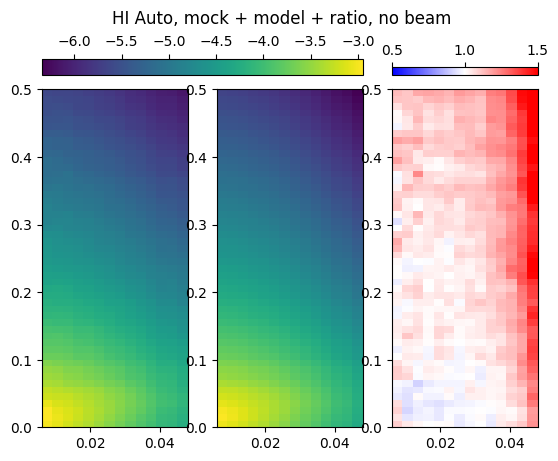

In [43]:
plt.rcParams.update({'font.size':10})
fig = plot_cy_power(
    kperpbins,
    kparabins,
    pdatacy_arr,
    pmodelcy_arr,
    0.5,
    1.5,
)
fig.suptitle('HI Auto, mock + model + ratio, no beam')

/users/ztchen/meer21cm/papers/validation/specs.py:51: RuntimeWarning: invalid value encountered in log10
  np.log10(pdatacy.mean(axis=0).T),
/users/ztchen/meer21cm/papers/validation/specs.py:61: RuntimeWarning: invalid value encountered in log10
  np.log10(pdatacy.mean(axis=0).T),


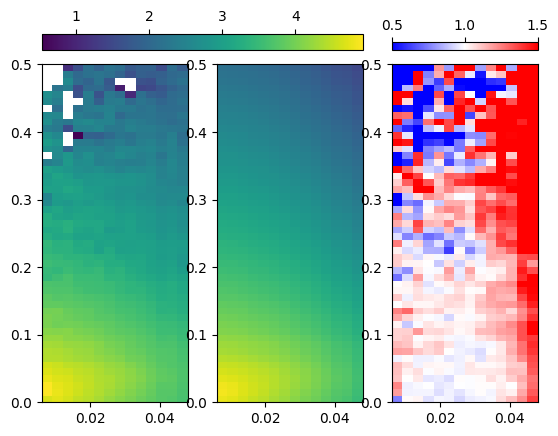

In [44]:
fig = plot_cy_power(
    kperpbins,
    kparabins,
    pgcy_arr,
    pgmodelcy_arr,
    0.5,
    1.5,
)

Text(0.5, 0.98, 'Cross, mock + model + ratio, no beam')

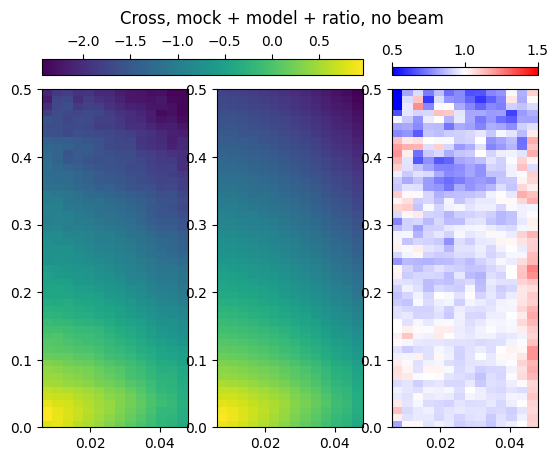

In [46]:
fig = plot_cy_power(
    kperpbins,
    kparabins,
    pxcy_arr,
    pxmodelcy_arr,
    0.5,
    1.5,
)
fig.suptitle('Cross, mock + model + ratio, no beam')

In [23]:
pdata1darr, keff, nmodes = bin_power_1d(
    data['pdata3d_arr'],
    kmode,
    k1dbins,
    k_xy_sel,
    num_split=20,
)
pmod1darr, keff, nmodes = bin_power_1d(
    data['phimod3d_arr'],
    kmode,
    k1dbins,
    k_xy_sel,
)
pmod1darr = pmod1darr[0]

pg1darr, keff, nmodes = bin_power_1d(
    data['pg3d_arr'],
    kmode,
    k1dbins,
    k_xy_sel,
    num_split=20,
)
pgmod1darr, keff, nmodes = bin_power_1d(
    data['pgmod3d_arr'],
    kmode,
    k1dbins,
    k_xy_sel,
)
pgmod1darr = pgmod1darr[0]

px1darr, keff, nmodes = bin_power_1d(
    data['pcross3d_arr'],
    kmode,
    k1dbins,
    k_xy_sel,
    num_split=20,
)
pxmod1darr, keff, nmodes = bin_power_1d(
    data['pcrossmod3d_arr'],
    kmode,
    k1dbins,
    k_xy_sel,
)
pxmod1darr = pxmod1darr[0]

/users/ztchen/meer21cm/papers/validation/specs.py:130: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


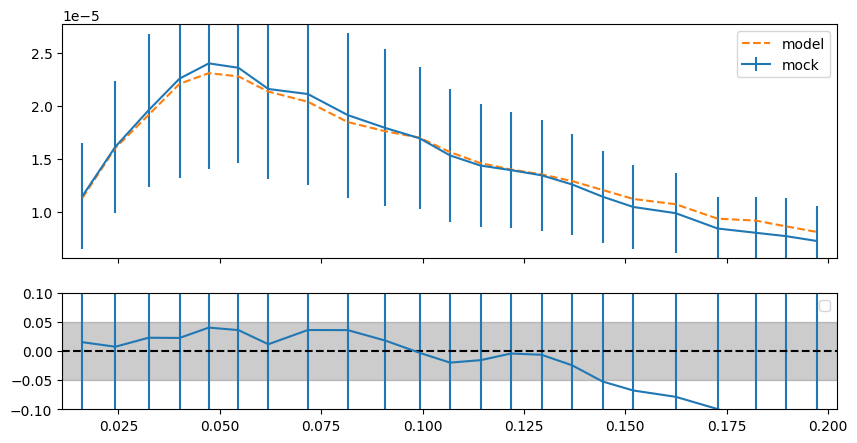

In [24]:
plot_1d_power(
        keff,
        pdata1darr,
        pmod1darr,
        -0.1,
        0.1,
    );

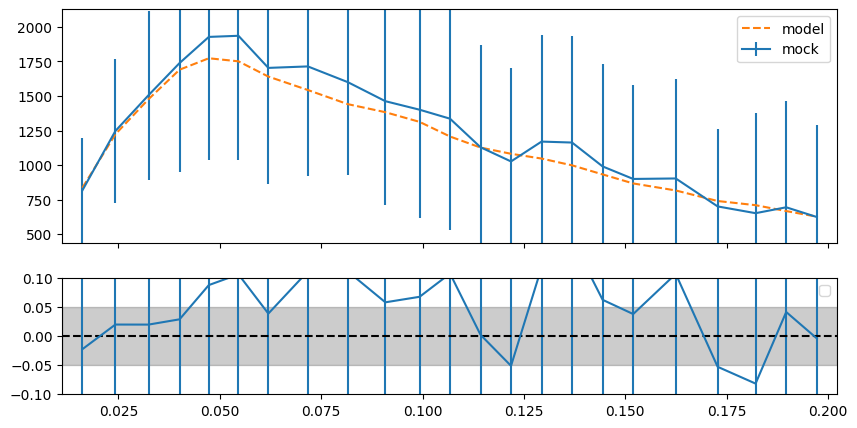

In [25]:
plot_1d_power(
        keff,
        pg1darr,
        pgmod1darr,
        -0.1,
        0.1,
    );

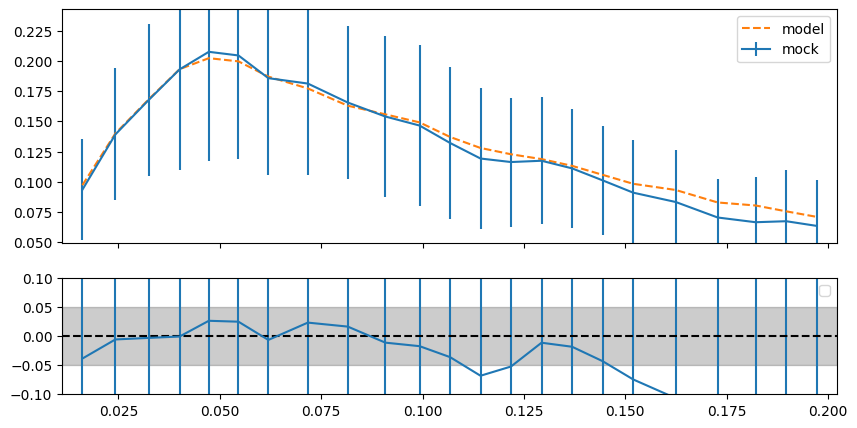

In [26]:
plot_1d_power(
        keff,
        px1darr,
        pxmod1darr,
        -0.1,
        0.1,
    );

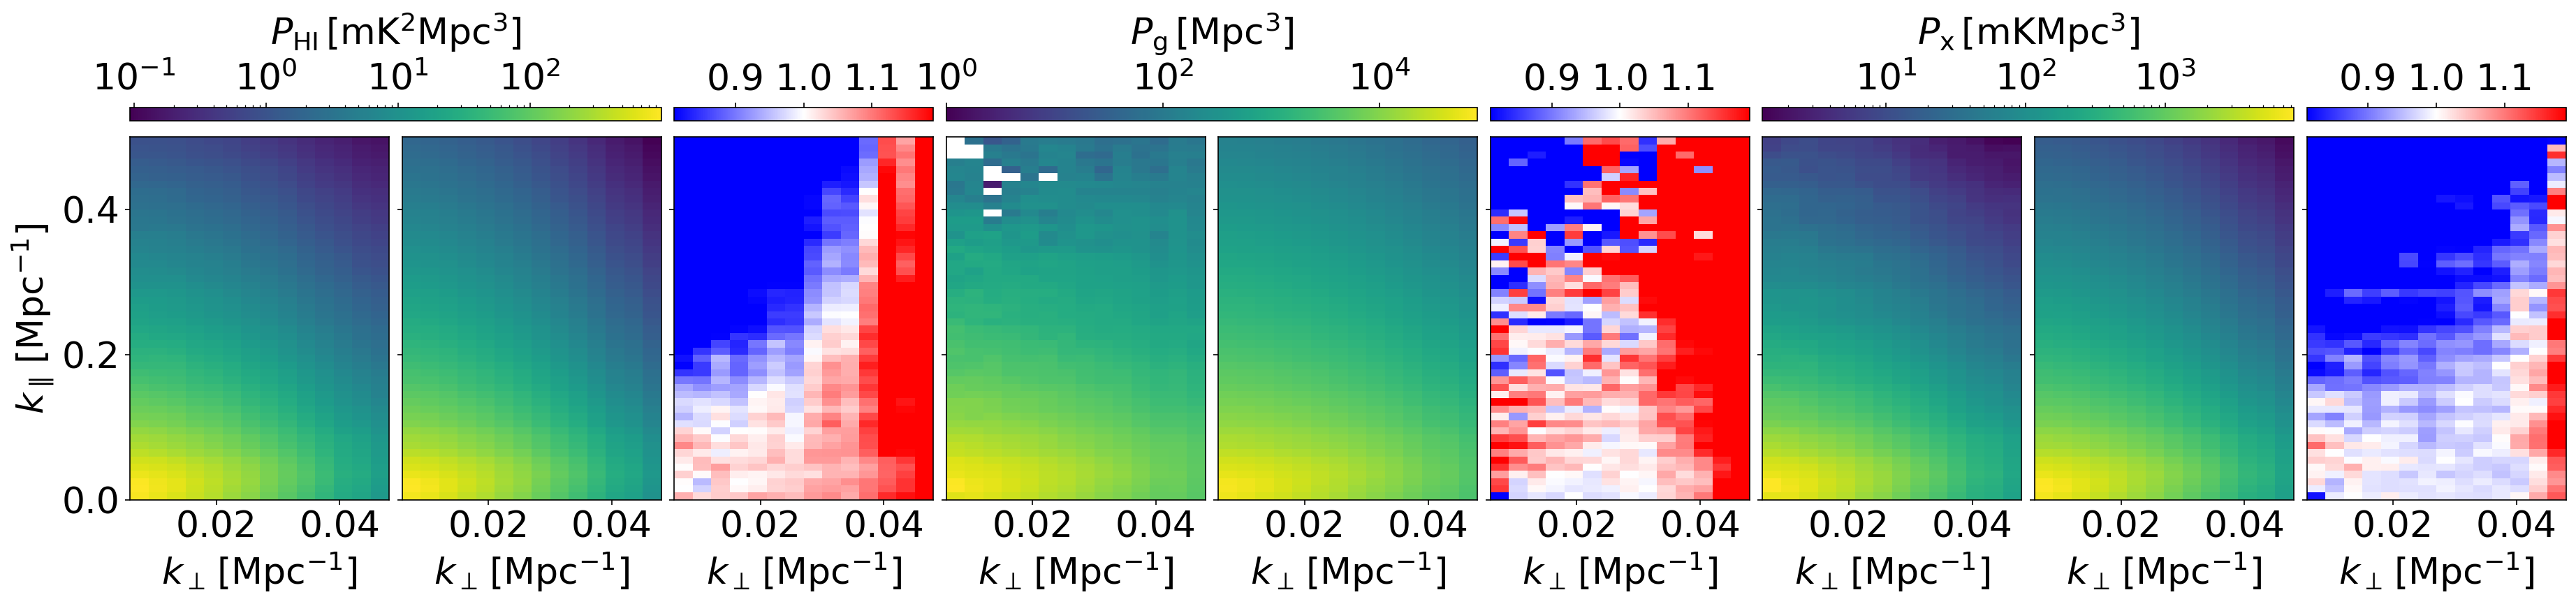

In [15]:
plt.rcParams['font.size'] = 25
fig, axes = plt.subplots(1, 9,figsize=(30,5),gridspec_kw={'wspace':0.05},dpi=150)
pmockarr = [pdatacy_arr*1e6,pgcy_arr,pxcy_arr*1e3]
pmodelarr = [pmodelcy_arr*1e6,pgmodelcy_arr,pxmodelcy_arr*1e3]
ylabelarr= [
    r'$P_{\rm HI}\,[{\rm mK^2 Mpc^3}]$',
    r'$P_{\rm g}\,[{\rm Mpc^3}]$',
    r'$P_{\rm x}\,[{\rm mK Mpc^3}]$',
]
for i in range(3):
    xbins = kperpbins
    ybins = kparabins
    pdatacy = pmockarr[i]
    pmodcy = pmodelarr[i]
    arr = np.array([
        (pdatacy.mean(axis=0).T),
        (pmodcy.T),
    ])
    vmin = np.nanmin(arr)
    if vmin<0:
        vmin = 1
    vmax = np.nanmax(arr)
    axes[0+i*3].pcolormesh(
        xbins,
        ybins,
        (pdatacy.mean(axis=0).T),
        norm=LogNorm(vmin=vmin, vmax=vmax)
    )
    if i>0:
        axes[0+i*3].set_yticklabels([])
    else:
        axes[0+i*3].set_ylabel(r'$k_\parallel\,[{\rm Mpc^{-1}}]$')
    im = axes[1+i*3].pcolormesh(
        xbins,
        ybins,
        (pmodcy.T),
        norm=LogNorm(vmin=vmin, vmax=vmax)
    )
    axes[1+i*3].set_yticklabels([])
    cbar = plt.colorbar(im,ax=axes[0+i*3:2+i*3],location="top",fraction=0.06,pad=0.04,aspect=40)
    cbar.set_label(ylabelarr[i],labelpad=12)
    im = axes[2+i*3].pcolormesh(
        xbins,
        ybins,
        (pdatacy.mean(axis=0).T) / (pmodcy.T),
        #vmin=vmin_ratio,
        #vmax=vmax_ratio,
        vmin=0.81,
        vmax=1.19,
        cmap="bwr",
    )
    axes[2+i*3].set_yticklabels([])
    cbar = plt.colorbar(im,ax=axes[2+i*3],location="top",fraction=0.06,pad=0.04)
    
for ax in axes:
    ax.set_xlabel(r'$k_\perp\,[{\rm Mpc^{-1}}]$')
plt.savefig('plots/01_cy.pdf',dpi=150, bbox_inches = "tight")

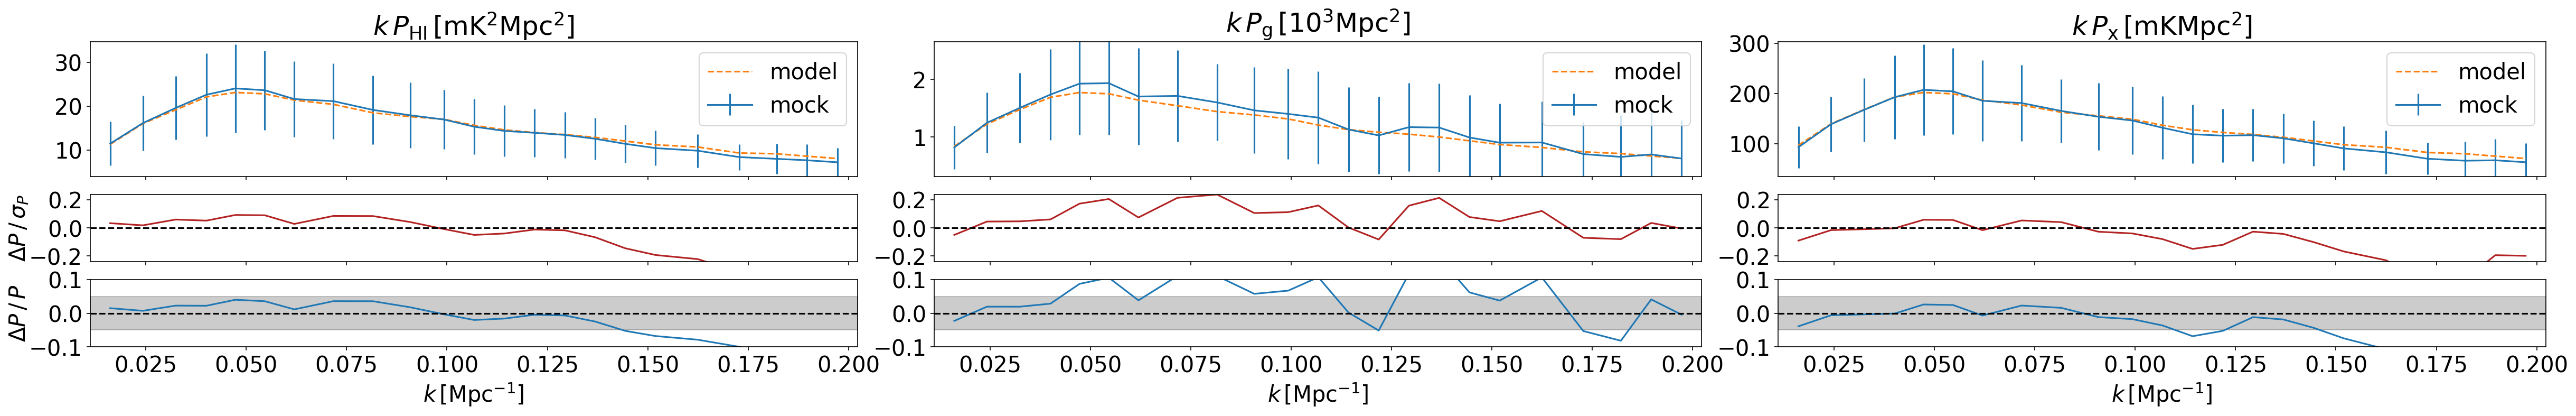

In [27]:
plt.rcParams['font.size'] = 20
fig,axes=plt.subplots(
    3,3,figsize=(40,5),sharex=True,
    height_ratios=[2,1,1],dpi=150,
    gridspec_kw={'wspace':0.1},
)
ratio_min,ratio_max = (-0.24,0.24)
pmockarr = [pdata1darr*1e6,pg1darr/1e3,px1darr*1e3]
pmodelarr = [pmod1darr*1e6,pgmod1darr/1e3,pxmod1darr*1e3]
titlearr = [r'HI power',r'Galaxy power',r'Cross power']
ylabelarr= [
    r'$k\,P_{\rm HI}\,[{\rm mK^2 Mpc^2}]$',
    r'$k\,P_{\rm g}\,[{\rm 10^3 Mpc^2}]$',
    r'$k\,P_{\rm x}\,[{\rm mK Mpc^2}]$',
]
for i in range(3):
    pdatad = pmockarr[i]
    pmodd = pmodelarr[i]
    axes[0,i].errorbar(
        keff,
        pdatad.mean(axis=0) * keff,
        yerr=pdatad.std(axis=0) * keff,
        label="mock",
    )
    axes[0,i].plot(keff, pmodd * keff, label="model", ls="--")
    axes[0,i].set_ylim((pmodd * keff).min() * 0.5, (pmodd * keff).max() * 1.5)
    axes[0,i].legend()
    #axes[0,i].set_ylabel(ylabelarr[i],labelpad=30)
    #axes[0,i].set_title(titlearr[i])
    axes[0,i].set_title(ylabelarr[i])
    axes[1,i].plot(
        keff,
        (pdatad.mean(axis=0)- pmodd) / (pdatad.std(axis=0)),
        #yerr=(pdatad.std(axis=0)) / (pmodd) / np.sqrt(len(pdatad)),
        color='firebrick',
    )
    axes[1,i].axhline(0, color="black", ls="--")
    #axes[1,i].fill_between(
    #    np.linspace(keff.min()-0.005,keff.max()+0.005,100), 
    #    -0.05, 0.05, color="black", alpha=0.2,
    #)
    #axes[1,i].fill_between(
    #    np.linspace(keff.min()-0.005,keff.max()+0.005,100), 
    #    -0.02, 0.02, color="black", alpha=0.2,
    #)
    axes[1,i].set_xlim(keff.min()-0.005,keff.max()+0.005)
    axes[1,i].set_ylim(ratio_min,ratio_max)
    if i == 0:
        axes[1,i].set_ylabel(r'$\Delta P \, / \,\sigma_P$',labelpad=-1)
    axes[2,i].plot(
        keff,
        (pdatad.mean(axis=0)) / (pmodd) - 1,
        #yerr=(pdatad.std(axis=0)) / (pmodd),
    )
    axes[2,i].axhline(0, color="black", ls="--")
    axes[2,i].fill_between(
        np.linspace(keff.min() - 0.005, keff.max() + 0.005, 100),
        -0.05,
        0.05,
        color="black",
        alpha=0.2,
    )
    axes[2,i].set_xlim(keff.min() - 0.005, keff.max() + 0.005)
    axes[2,i].set_ylim(-0.1, 0.1)
    #axes[2,i].set_yscale('symlog',linthresh=0.05)
    #axes[2,i].set_yticks([-0.15,-0.05,0,0.05,0.15])
    #axes[2,i].set_yticklabels(['-0.15','-0.05','','0.05','0.15'])
    #axes[2,i].legend()
    axes[2,i].set_xlabel(r'$k\,[{\rm Mpc^{-1}}]$')
    if i ==0:
        axes[2,i].set_ylabel(r'$\Delta P \, / \,P$',labelpad=-1)
        
plt.savefig('plots/01_1d.pdf',dpi=150, bbox_inches = "tight")

In [60]:
from scipy.interpolate import interp1d
if True:
    z_func = interp1d(
        z_cen, z_count / dV_arr, kind="linear", bounds_error=False, fill_value=0
    )
    mock = MockSimulation(
        wproj=wcs,
        num_pix_x=num_pix_x,
        num_pix_y=num_pix_y,
        ra_range=ra_range,
        dec_range=dec_range,
        nu=nu_arr,
        mean_amp_1="average_hi_temp",
        omega_hi=5e-4,
        discrete_source_dndz=z_func,
    )
    mock.downres_factor_transverse = 3
    mock.downres_factor_radial = 6
    mock.get_enclosing_box()
    mock.counts_in_box.shape
    dndz_box = mock.discrete_source_dndz(mock._box_voxel_redshift)
    
    

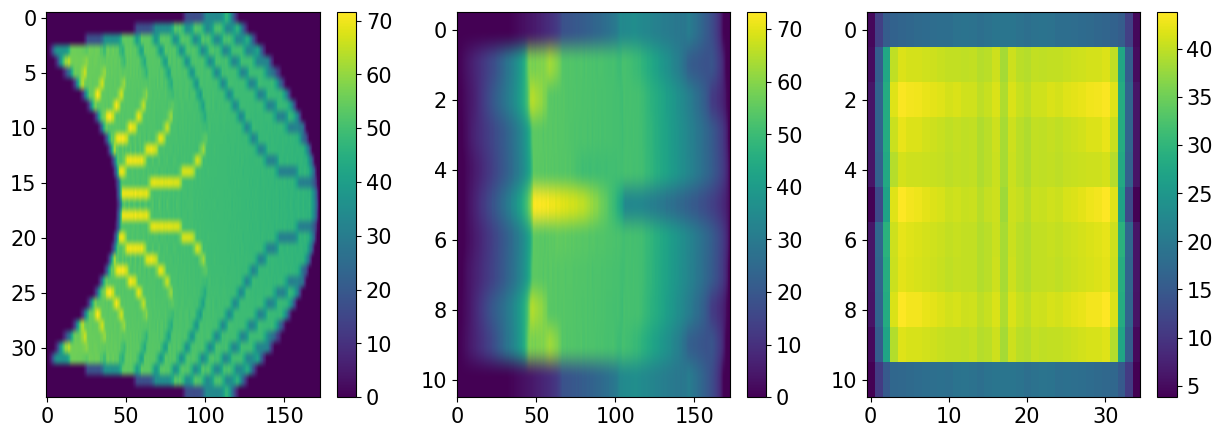

In [63]:
plt.rcParams['font.size'] = 15

fig,axes = plt.subplots(1,3, figsize=(15,5))
for i in range(3):
    im = axes[i].imshow(mock.counts_in_box.mean(i),aspect='auto')
    plt.colorbar(im)

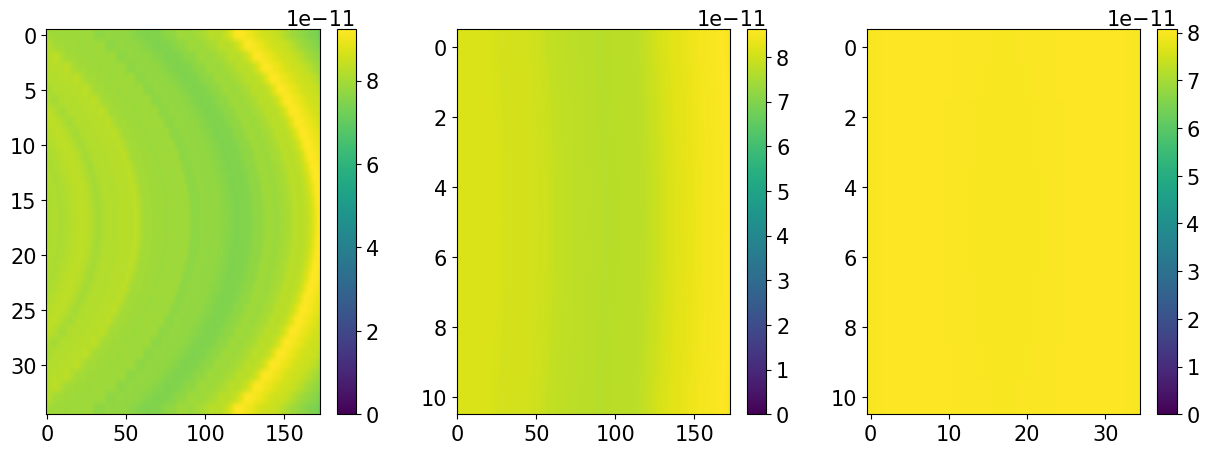

In [67]:
plt.rcParams['font.size'] = 15
fig,axes = plt.subplots(1,3, figsize=(15,5))
for i in range(3):
    im = axes[i].imshow(dndz_box.mean(i),aspect='auto',vmin=0)
    plt.colorbar(im)

Text(0, 0.5, 'dN/dz')

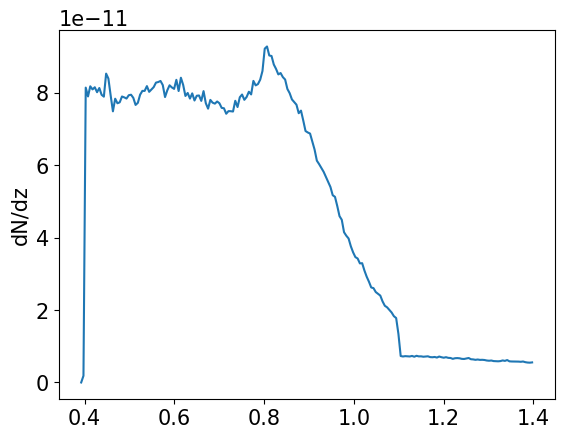

In [66]:
plt.plot(z_cen,z_func(z_cen))
plt.ylabel('dN/dz')

In [2]:
import numpy as np
np.array_split(np.arange(128,256),4)

[array([128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140,
        141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153,
        154, 155, 156, 157, 158, 159]),
 array([160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172,
        173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185,
        186, 187, 188, 189, 190, 191]),
 array([192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204,
        205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217,
        218, 219, 220, 221, 222, 223]),
 array([224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236,
        237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249,
        250, 251, 252, 253, 254, 255])]